## Steam Games: SQL Analysis and EDA

This notebook answers six questions about the Steam catalogue using SQL against the cleaned database produced in 01_data_cleaning_and_setup.ipynb. Each question is a SQL query first; pandas and plots are used only to display results.

##### Contents: 1 Setup · 2 Free-to-play trend · 3 Genres · 4 Publishers · 5 Price vs Metacritic · 6 Platforms · 7 Discounts · 8 Findings

## 1. Setup and Orientation

##### 1.1 Connect (read-only)

In [1]:
# 1.1 Connect to the cleaned database (read-only, so analysis can never alter it)
import duckdb
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

con = duckdb.connect()
con.sql("INSTALL sqlite; LOAD sqlite;")
con.sql("ATTACH '../data/processed/steam_clean.sqlite' AS clean (TYPE sqlite, READ_ONLY)")
con.sql("USE clean")

def q(sql):
    """Run a SQL query and return a DataFrame."""
    return con.sql(sql).df()

SCRAPE_DATE = '2025-09-29'   # release_year 2025 covers Jan 1 to this date only
print(q("SHOW TABLES").to_string(index=False))

           name
     categories
     developers
game_categories
game_developers
    game_genres
 game_platforms
game_publishers
          games
         genres
      platforms
     publishers


#### 1.2 Orientation checks

In [2]:
# 1.2 Confirm the database matches notebook 01
print(q("""
    SELECT COUNT(*)                        AS games,
           CAST(SUM(is_free) AS INTEGER)   AS free_games,
           COUNT(release_year)             AS with_release_year,
           MIN(release_year)               AS first_year,
           MAX(release_year)               AS last_year,
           COUNT(price_usd)                AS usd_priced,
           COUNT(metacritic_score)         AS with_metacritic
    FROM games
""").to_string(index=False))

print(q("""
    SELECT release_year, COUNT(*) AS games
    FROM games
    WHERE release_year >= 2022
    GROUP BY release_year ORDER BY release_year
""").to_string(index=False))


 games  free_games  with_release_year  first_year  last_year  usd_priced  with_metacritic
150279       18994             114955        1997       2025       88943             4166
 release_year  games
         2022  12311
         2023  14664
         2024  20203
         2025  17236


## 2. Free-to-Play Share by Release Year

#### 2.1 Two definitions of free

In [3]:
# 2.1 Compare the two definitions of "free"
print(q("SELECT genre_id, genre_name FROM genres WHERE genre_name ILIKE '%free%'").to_string(index=False))

print(q("""
    WITH tagged AS (
        SELECT DISTINCT gg.appid
        FROM game_genres gg
        JOIN genres ge USING (genre_id)
        WHERE ge.genre_name ILIKE '%free%'
    )
    SELECT g.is_free,
           (t.appid IS NOT NULL) AS has_free_genre_tag,
           COUNT(*)              AS games
    FROM games g
    LEFT JOIN tagged t USING (appid)
    GROUP BY 1, 2 ORDER BY 1, 2
""").to_string(index=False))

 genre_id   genre_name
       13 Free to Play
 is_free  has_free_genre_tag  games
       0               False 130862
       0                True    423
       1               False   5692
       1                True  13302


#### 2.1b Characterise the disagreements

In [4]:
# 2.1b Who are the 5,692 free games without the tag, and the 423 paid games with it?
print(q("""
    WITH tagged AS (
        SELECT DISTINCT appid FROM game_genres
        WHERE genre_id = (SELECT genre_id FROM genres WHERE genre_name = 'Free to Play')
    ),
    any_genre AS (SELECT DISTINCT appid FROM game_genres)
    SELECT CASE WHEN a.appid IS NULL THEN 'no genre rows at all'
                ELSE 'has other genres' END AS free_untagged_group,
           COUNT(*) AS games
    FROM games g
    LEFT JOIN any_genre a USING (appid)
    WHERE g.is_free = 1 AND g.appid NOT IN (SELECT appid FROM tagged)
    GROUP BY 1
""").to_string(index=False))

print(q("""
    SELECT COUNT(*)                AS paid_but_tagged,
           COUNT(price_usd)        AS with_usd_price,
           MEDIAN(price_usd)       AS median_price_usd,
           MIN(price_usd)          AS min_price_usd,
           MAX(price_usd)          AS max_price_usd
    FROM games
    WHERE is_free = 0
      AND appid IN (SELECT appid FROM game_genres
                    WHERE genre_id = (SELECT genre_id FROM genres WHERE genre_name = 'Free to Play'))
""").to_string(index=False))

print(q("""
    SELECT appid, name, price_usd, release_year
    FROM games
    WHERE is_free = 0
      AND appid IN (SELECT appid FROM game_genres
                    WHERE genre_id = (SELECT genre_id FROM genres WHERE genre_name = 'Free to Play'))
    ORDER BY appid LIMIT 8
""").to_string(index=False))

 free_untagged_group  games
    has other genres   5672
no genre rows at all     20
 paid_but_tagged  with_usd_price  median_price_usd  min_price_usd  max_price_usd
             423             100              4.99           0.99          29.99
 appid                                                       name  price_usd  release_year
 24800                  Command & Conquer: Red Alert 3 - Uprising        NaN          2009
209870                                    Blacklight: Retribution        NaN          2012
215120                                                ROSE Online        NaN          2012
232450                                                   SolForge        NaN          2016
234820 Driver Fusion - The Best Driver Update and Backup Software        NaN          2013
236130                                                    Horizon      29.99          2014
247710                                                Battledroid        NaN          <NA>
266150                    

#### Decision:
definition of free. is_free is the primary definition. It has no missing values, whereas the "Free to Play" genre tag is absent on 5,692 of 18,994 free games (30%) and present on 423 paid games (0.3%). Most of those 423 have no USD price, so some may be free-to-play listings flagged as paid. The tag-based share is shown alongside as a robustness check.

#### 2.2 Free share by release year, with both definitions

In [5]:
# 2.2 Free-to-play share by release year: is_free flag vs "Free to Play" genre tag
yearly = q("""
    WITH tagged AS (
        SELECT DISTINCT appid FROM game_genres
        WHERE genre_id = (SELECT genre_id FROM genres WHERE genre_name = 'Free to Play')
    )
    SELECT g.release_year,
           COUNT(*)                                        AS games,
           CAST(SUM(g.is_free) AS INTEGER)                 AS free_flag,
           ROUND(100.0 * AVG(g.is_free), 1)                AS pct_free_flag,
           ROUND(100.0 * AVG((t.appid IS NOT NULL)::INT), 1) AS pct_free_tag
    FROM games g
    LEFT JOIN tagged t USING (appid)
    WHERE g.release_year IS NOT NULL
    GROUP BY g.release_year
    ORDER BY g.release_year
""")
print(yearly.to_string(index=False))

# Are games without a valid release date different? (they are excluded above)
print(q("""
    SELECT CASE WHEN release_year IS NULL THEN 'no valid date' ELSE 'has valid date' END AS grp,
           COUNT(*) AS games,
           CAST(SUM(is_free) AS INTEGER) AS free_games,
           ROUND(100.0 * AVG(is_free), 1) AS pct_free
    FROM games GROUP BY 1 ORDER BY 1
""").to_string(index=False))

 release_year  games  free_flag  pct_free_flag  pct_free_tag
         1997      2          1          50.00          0.00
         1998      1          0           0.00          0.00
         1999      2          0           0.00          0.00
         2000      2          0           0.00          0.00
         2001      4          0           0.00          0.00
         2002      1          0           0.00          0.00
         2003      3          0           0.00          0.00
         2004      5          0           0.00          0.00
         2005      7          0           0.00          0.00
         2006     63          1           1.60          0.00
         2007     84          2           2.40          2.40
         2008    151          3           2.00          1.30
         2009    307          7           2.30          1.00
         2010    240          7           2.90          1.70
         2011    252         15           6.00          4.40
         2012    320    

#### 2.2b Test the tag jump

In [6]:
# 2.2b Share carrying the "Free to Play" tag, split by is_free, recent years
print(q("""
    WITH tagged AS (
        SELECT DISTINCT appid FROM game_genres
        WHERE genre_id = (SELECT genre_id FROM genres WHERE genre_name = 'Free to Play')
    )
    SELECT g.release_year, g.is_free, COUNT(*) AS games,
           ROUND(100.0 * AVG((t.appid IS NOT NULL)::INT), 1) AS pct_tagged
    FROM games g
    LEFT JOIN tagged t USING (appid)
    WHERE g.release_year BETWEEN 2021 AND 2025
    GROUP BY 1, 2 ORDER BY 1, 2
""").to_string(index=False))

 release_year  is_free  games  pct_tagged
         2021        0   9520        0.10
         2021        1   1546       59.40
         2022        0  10385        0.10
         2022        1   1926       60.90
         2023        0  12487        0.10
         2023        1   2177       57.00
         2024        0  17081        0.20
         2024        1   3122       86.90
         2025        0  15126        0.10
         2025        1   2110       97.10


#### 2.3 Chart

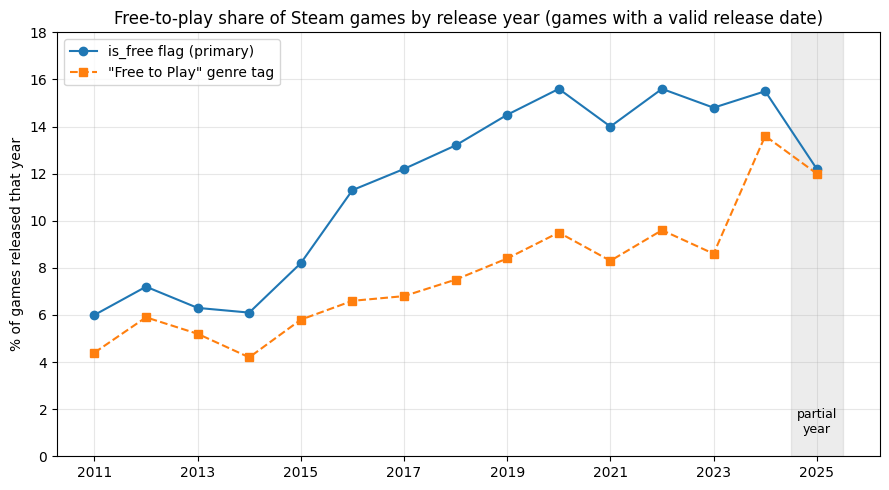

In [7]:
# 2.3 Free-to-play share by release year
import matplotlib.pyplot as plt
from pathlib import Path

plot_df = yearly[yearly['release_year'] >= 2011]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(plot_df['release_year'], plot_df['pct_free_flag'], marker='o', label='is_free flag (primary)')
ax.plot(plot_df['release_year'], plot_df['pct_free_tag'], marker='s', linestyle='--',
        label='"Free to Play" genre tag')
ax.axvspan(2024.5, 2025.5, color='grey', alpha=0.15)
ax.text(2025, 1, 'partial\nyear', ha='center', fontsize=9)
ax.set_xticks(range(2011, 2026, 2))
ax.set_ylim(0, 18)
ax.set_ylabel('% of games released that year')
ax.set_title('Free-to-play share of Steam games by release year (games with a valid release date)')
ax.grid(alpha=0.3)
ax.legend(loc='upper left')
plt.tight_layout()

Path('../docs/figures').mkdir(parents=True, exist_ok=True)
fig.savefig('../docs/figures/q1_free_share_by_year.png', dpi=150)
plt.show()

#### Q1 conclusion: free-to-play share by release year.
Under the is_free flag, the free share of games rose from about 2-3% (2006-2010) to 6.0% in 2011, 11.3% in 2016 and 13.2% in 2018, stayed in a band of 14.0% to 15.6%. Each of those years has more than 7,000 games with a valid release date. The 2025 value (12.2%) covers January to 29 September only and is not evidence of a decline.

The "Free to Play" genre tag shows the same rise and plateau through 2023 (4.4% in 2011, 8.4% in 2019, 8.6% in 2023), at a lower level, because it is applied to only about 60% of free games. In 2024-2025 the tag share converges with the flag share. This comes from free games only: 86.9% of free games carry the tag in 2024 and 97.1% in 2025, against 57-61% in 2021-2023, while paid games stay below 0.2% throughout. The cause is not determined from this data.

Limits. Shares exclude the 35,324 games (23.5%) with no valid release date, which are less often free (8.9% vs 13.8%). Years before 2011 have too few games to interpret and are omitted from the chart.

## 3. Genre Dynamics

#### 3.1 Genre share by release year

In [8]:
# 3.1 Genre share by release year. A game counts once per genre it carries,
# so shares across genres sum to more than 100%.
genre_year = q("""
    WITH yearly_totals AS (
        SELECT g.release_year, COUNT(DISTINCT g.appid) AS games_with_genre
        FROM games g
        JOIN game_genres gg USING (appid)
        WHERE g.release_year BETWEEN 2015 AND 2024
        GROUP BY g.release_year
    ),
    genre_counts AS (
        SELECT g.release_year, ge.genre_name, COUNT(*) AS games
        FROM games g
        JOIN game_genres gg USING (appid)
        JOIN genres ge USING (genre_id)
        WHERE g.release_year BETWEEN 2015 AND 2024
        GROUP BY g.release_year, ge.genre_name
    )
    SELECT c.release_year, c.genre_name, c.games,
           ROUND(100.0 * c.games / t.games_with_genre, 1) AS pct_of_games,
           RANK() OVER (PARTITION BY c.release_year ORDER BY c.games DESC) AS rank_in_year
    FROM genre_counts c
    JOIN yearly_totals t USING (release_year)
    ORDER BY c.release_year, rank_in_year
""")
print(genre_year[genre_year['rank_in_year'] <= 5].to_string(index=False))

 release_year genre_name  games  pct_of_games  rank_in_year
         2015      Indie   1828         73.10             1
         2015     Action   1084         43.40             2
         2015  Adventure    978         39.10             3
         2015     Casual    753         30.10             4
         2015   Strategy    559         22.40             5
         2016      Indie   2918         70.60             1
         2016     Action   1802         43.60             2
         2016     Casual   1560         37.70             3
         2016  Adventure   1522         36.80             4
         2016 Simulation    791         19.10             5
         2017      Indie   4223         71.40             1
         2017     Action   2618         44.30             2
         2017     Casual   2372         40.10             3
         2017  Adventure   2270         38.40             4
         2017 Simulation   1123         19.00             5
         2018      Indie   5735         

#### 3.2 Growth: which genres are gaining or losing share?


In [9]:
# 3.2 Change in genre share, 2015-2017 average vs 2022-2024 average, plus LAG year-over-year
growth = q("""
    WITH totals AS (
        SELECT g.release_year, COUNT(DISTINCT g.appid) AS n
        FROM games g JOIN game_genres gg USING (appid)
        WHERE g.release_year BETWEEN 2015 AND 2024
        GROUP BY 1
    ),
    shares AS (
        SELECT g.release_year, ge.genre_name,
               COUNT(*) AS games,
               100.0 * COUNT(*) / ANY_VALUE(t.n) AS pct
        FROM games g
        JOIN game_genres gg USING (appid)
        JOIN genres ge USING (genre_id)
        JOIN totals t ON t.release_year = g.release_year
        WHERE g.release_year BETWEEN 2015 AND 2024
        GROUP BY g.release_year, ge.genre_name
    ),
    periods AS (
        SELECT genre_name,
               AVG(pct) FILTER (WHERE release_year BETWEEN 2015 AND 2017) AS early_pct,
               AVG(pct) FILTER (WHERE release_year BETWEEN 2022 AND 2024) AS late_pct,
               CAST(SUM(games) AS INTEGER) AS total_games
        FROM shares GROUP BY genre_name
    )
    SELECT genre_name, total_games,
           ROUND(early_pct, 1) AS early_pct, ROUND(late_pct, 1) AS late_pct,
           ROUND(late_pct - early_pct, 1) AS change_pts
    FROM periods
    WHERE total_games >= 1000
    ORDER BY change_pts DESC
""")
print(growth.to_string(index=False))

yoy = q("""
    WITH totals AS (
        SELECT g.release_year, COUNT(DISTINCT g.appid) AS n
        FROM games g JOIN game_genres gg USING (appid)
        WHERE g.release_year BETWEEN 2015 AND 2024
        GROUP BY 1
    ),
    shares AS (
        SELECT g.release_year, ge.genre_name,
               100.0 * COUNT(*) / ANY_VALUE(t.n) AS pct
        FROM games g
        JOIN game_genres gg USING (appid)
        JOIN genres ge USING (genre_id)
        JOIN totals t ON t.release_year = g.release_year
        WHERE g.release_year BETWEEN 2015 AND 2024 AND ge.genre_name IN ('Casual', 'Action', 'Simulation')
        GROUP BY g.release_year, ge.genre_name
    )
    SELECT release_year, genre_name, ROUND(pct, 1) AS pct,
           ROUND(pct - LAG(pct) OVER (PARTITION BY genre_name ORDER BY release_year), 1) AS yoy_change_pts
    FROM shares
    ORDER BY genre_name, release_year
""")
print(yoy.to_string(index=False))

           genre_name  total_games  early_pct  late_pct  change_pts
               Casual        39281      36.00     45.40        9.40
         Free to Play         8935       6.40     11.70        5.30
                  RPG        16188      15.80     19.50        3.70
           Simulation        18385      18.60     21.50        2.90
         Early Access         8657       7.60     10.40        2.80
            Adventure        35654      38.10     40.80        2.70
               Racing         3238       3.40      3.70        0.30
             Strategy        17153      19.60     19.70        0.00
Massively Multiplayer         2060       2.20      2.30        0.00
               Sports         3969       4.90      4.10       -0.70
                Indie        63718      71.70     68.90       -2.80
               Action        36730      43.70     40.30       -3.50
 release_year genre_name   pct  yoy_change_pts
         2015     Action 43.40             NaN
         2016     Acti

#### 3.3 Chart and Q2 conclusion

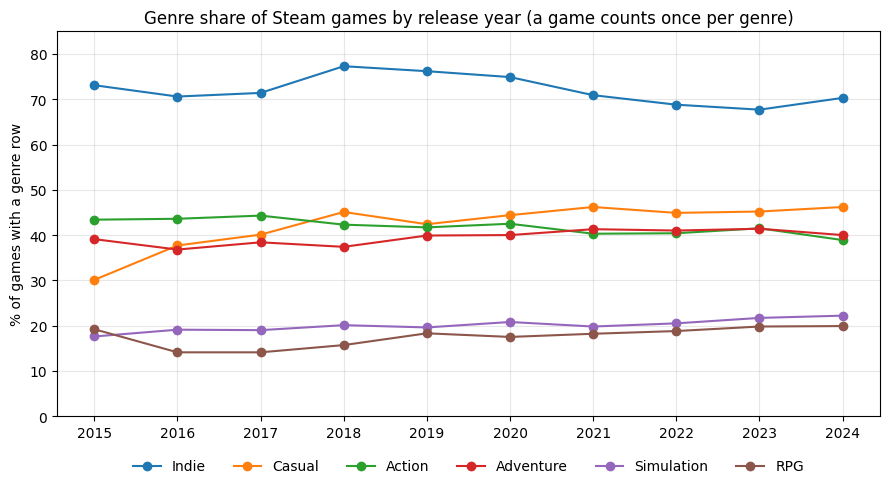

In [10]:
# 3.3 Genre share by release year (2015-2024)
import matplotlib.pyplot as plt

genres_to_plot = ['Indie', 'Casual', 'Action', 'Adventure', 'Simulation', 'RPG']
fig, ax = plt.subplots(figsize=(9, 5))
for name in genres_to_plot:
    d = genre_year[genre_year['genre_name'] == name].sort_values('release_year')
    ax.plot(d['release_year'], d['pct_of_games'], marker='o', label=name)
ax.set_xticks(range(2015, 2025))
ax.set_ylim(0, 85)
ax.set_ylabel('% of games with a genre row')
ax.set_title('Genre share of Steam games by release year (a game counts once per genre)')
ax.grid(alpha=0.3)
ax.legend(ncol=6, loc='upper center', bbox_to_anchor=(0.5, -0.08), frameon=False)
plt.tight_layout()
fig.savefig('../docs/figures/q2_genre_share_by_year.png', dpi=150)
plt.show()

#### Q2 conclusion: genre share by release year.
Indie is the most common genre in every year from 2015 to 2024, at 67.7-77.3% of games with a genre row. Casual rose from 30.1% (2015) to 45.1% (2018) and has stayed between 42.4% and 46.2% since, overtaking Action in 2018. Action fell from 44.3% (2017) to 38.9% (2024). Simulation rose steadily from 17.6% to 22.2% and has been the fifth most common genre since 2016. RPG fell from about 19% (2015) to about 14% (2016-2017), then recovered to about 20% by 2024; its +3.7-point gain between the 2015-2017 and 2022-2024 averages is sensitive to that early dip.

Limits. A game counts once per genre, so shares sum above 100%. Games with no genre row (about 5%) are excluded. Growth figures depend on the comparison window (Casual's gain would be roughly halved with 2016-2018 as the early period). The "Free to Play" tag is omitted from interpretation because its application changed in 2024 (Section 2).

## 4. Publisher Catalogue Size vs Reception

#### 4.1 Check the coverage before choosing a measure

In [11]:
# 4.1 How many publishers and games have each reception measure?
print(q("""
    WITH pub_size AS (
        SELECT publisher_id, COUNT(DISTINCT appid) AS catalogue
        FROM game_publishers GROUP BY publisher_id
    )
    SELECT CASE WHEN ps.catalogue = 1 THEN '1 game'
                WHEN ps.catalogue BETWEEN 2 AND 5 THEN '2-5 games'
                WHEN ps.catalogue BETWEEN 6 AND 20 THEN '6-20 games'
                ELSE '21+ games' END AS catalogue_band,
           COUNT(DISTINCT ps.publisher_id)                        AS publishers,
           COUNT(DISTINCT gp.appid)                               AS games,
           COUNT(DISTINCT CASE WHEN g.metacritic_score IS NOT NULL THEN gp.appid END)      AS with_metacritic,
           COUNT(DISTINCT CASE WHEN g.recommendations_total IS NOT NULL THEN gp.appid END) AS with_recs
    FROM pub_size ps
    JOIN game_publishers gp USING (publisher_id)
    JOIN games g USING (appid)
    GROUP BY 1
    ORDER BY MIN(ps.catalogue)
""").to_string(index=False))

catalogue_band  publishers  games  with_metacritic  with_recs
        1 game       61423  60628              474       3420
     2-5 games       16860  42765              885       5611
    6-20 games        1980  18235              948       4385
     21+ games         470  23094             2054       7372


#### 4.2 Publisher-level reception by catalogue band

In [12]:
# 4.2 Reception by publisher catalogue size (a game counts once per publisher)
print(q("""
    WITH pub AS (
        SELECT gp.publisher_id,
               COUNT(*)                          AS catalogue,
               COUNT(g.recommendations_total)    AS n_recs,
               MEDIAN(g.recommendations_total)   AS median_recs,
               COUNT(g.metacritic_score)         AS n_meta,
               AVG(g.metacritic_score)           AS avg_meta
        FROM game_publishers gp
        JOIN games g USING (appid)
        GROUP BY gp.publisher_id
    ),
    banded AS (
        SELECT *, CASE WHEN catalogue = 1 THEN '1 game'
                       WHEN catalogue BETWEEN 2 AND 5 THEN '2-5 games'
                       WHEN catalogue BETWEEN 6 AND 20 THEN '6-20 games'
                       ELSE '21+ games' END AS catalogue_band
        FROM pub
    )
    SELECT catalogue_band,
           COUNT(*)                                              AS publishers,
           ROUND(100.0 * SUM(n_recs) / SUM(catalogue), 1)        AS pct_games_with_recs,
           ROUND(MEDIAN(median_recs), 0)                         AS median_of_pub_medians,
           COUNT(*) FILTER (WHERE n_meta >= 3)                   AS pubs_with_3plus_scores,
           ROUND(AVG(avg_meta) FILTER (WHERE n_meta >= 3), 1)    AS avg_metacritic
    FROM banded
    GROUP BY catalogue_band
    ORDER BY MIN(catalogue)
""").to_string(index=False))

catalogue_band  publishers  pct_games_with_recs  median_of_pub_medians  pubs_with_3plus_scores  avg_metacritic
        1 game       61423                 5.70                 327.00                       0             NaN
     2-5 games       16860                13.20                 353.00                      43           76.70
    6-20 games        1980                24.30                 322.00                     142           75.20
     21+ games         470                32.80                 322.00                     129           74.10


#### 4.3 Catalogue band vs recommendation coverage, within release-year cohorts

In [13]:
# 4.3 Does the catalogue-size gradient survive within release-year cohorts?
print(q("""
    WITH pub AS (
        SELECT publisher_id, COUNT(*) AS catalogue
        FROM game_publishers GROUP BY publisher_id
    ),
    pairs AS (
        SELECT g.recommendations_total, p.catalogue,
               CASE WHEN g.release_year BETWEEN 2011 AND 2015 THEN '2011-2015'
                    WHEN g.release_year BETWEEN 2016 AND 2019 THEN '2016-2019'
                    WHEN g.release_year BETWEEN 2020 AND 2022 THEN '2020-2022'
                    ELSE '2023-2025' END AS cohort
        FROM game_publishers gp
        JOIN pub p USING (publisher_id)
        JOIN games g USING (appid)
        WHERE g.release_year BETWEEN 2011 AND 2025
    )
    SELECT cohort,
           CASE WHEN catalogue = 1 THEN '1 game'
                WHEN catalogue <= 5 THEN '2-5 games'
                WHEN catalogue <= 20 THEN '6-20 games'
                ELSE '21+ games' END AS catalogue_band,
           COUNT(*) AS publisher_game_pairs,
           ROUND(100.0 * COUNT(recommendations_total) / COUNT(*), 1) AS pct_with_recs
    FROM pairs
    GROUP BY cohort, catalogue_band
    ORDER BY cohort, MIN(catalogue)
""").to_string(index=False))

   cohort catalogue_band  publisher_game_pairs  pct_with_recs
2011-2015         1 game                  1062          36.70
2011-2015      2-5 games                  1295          55.90
2011-2015     6-20 games                   988          63.70
2011-2015      21+ games                  1891          65.60
2016-2019         1 game                  8438          10.60
2016-2019      2-5 games                  7717          20.90
2016-2019     6-20 games                  3804          32.20
2016-2019      21+ games                  5374          39.30
2020-2022         1 game                 10821           7.60
2020-2022      2-5 games                  9547          15.10
2020-2022     6-20 games                  4616          25.50
2020-2022      21+ games                  6627          30.50
2023-2025         1 game                 19758           6.80
2023-2025      2-5 games                 14588          12.60
2023-2025     6-20 games                  6288          21.10
2023-202

#### 4.4 Q3 conclusion: publisher catalogue size vs reception.
Publisher catalogues are heavily skewed: 76.1% of the 80,733 publishers have one game and only 470 have 21 or more. Reception is sparse, with Metacritic on 4,166 games (2.8%) and recommendations reported for 13.2%, so reception was measured as the share of a publisher's games with recommendations reported. That share rises from 5.7% (1 game) to 13.2%, 24.3% and 32.8% (21+ games). Among games that report, the median recommendation count is flat across bands (322-353), so the difference lies in how many games are reported, not in the size of the counts. Average Metacritic for publishers with at least 3 scored games drifts from 76.7 (43 publishers) to 74.1 (129), a small gap on selected samples that was not tested.

Within release-year cohorts the gradient remains in all four, with a 1-game-to-21+ gap of 29.0, 28.7, 22.9 and 20.7 points from oldest to newest cohort, so publisher age alone does not explain it. Small publishers' games are more recent, which adds to the pooled gap.

Limits. Recommendations measure reach, not quality. Catalogue size counts only games (not DLC or demos) and uses IDs merged by trimmed lowercased name; other name variants may split a publisher. A game counts once per publisher. The Metacritic comparison is not representative of publishers in general.

## 5. Q4: Price tier versus Metacritic score

**Question.** Do higher-priced games receive higher Metacritic scores?

**Approach.** Tiers are based on list price in USD (`price_usd`); free games are identified by `is_free`. Before comparing scores, coverage is checked per tier, because only a small share of games has a Metacritic score and price is missing more often for recent listings.

In [14]:
coverage_sql = """
SELECT
    CASE
        WHEN is_free = 1        THEN '0 Free'
        WHEN price_usd IS NULL  THEN '6 Paid, no USD price'
        WHEN price_usd < 5      THEN '1 Under $5'
        WHEN price_usd < 10     THEN '2 $5 to 9.99'
        WHEN price_usd < 20     THEN '3 $10 to 19.99'
        WHEN price_usd < 40     THEN '4 $20 to 39.99'
        ELSE                         '5 $40 and above'
    END AS tier,
    COUNT(*)                                              AS games,
    COUNT(metacritic_score)                               AS scored,
    ROUND(100.0 * COUNT(metacritic_score) / COUNT(*), 1)  AS pct_scored
FROM games
GROUP BY 1
ORDER BY 1
"""
coverage = q(coverage_sql)
display(coverage)
print("Total games:", coverage["games"].sum(), "| total scored:", coverage["scored"].sum())

,tier,games,scored,pct_scored
0,0 Free,18994,114,0.60
1,1 Under $5,43861,350,0.80
2,2 $5 to 9.99,23359,986,4.20
3,3 $10 to 19.99,16060,1590,9.90
4,4 $20 to 39.99,4316,674,15.60
5,5 $40 and above,1347,142,10.50
6,"6 Paid, no USD price",42342,310,0.70


Total games: 150279 | total scored: 4166


#### Score distribution by price tier

In [15]:
score_by_tier_sql = """
SELECT
    CASE
        WHEN is_free = 1        THEN '0 Free'
        WHEN price_usd < 5      THEN '1 Under $5'
        WHEN price_usd < 10     THEN '2 $5 to 9.99'
        WHEN price_usd < 20     THEN '3 $10 to 19.99'
        WHEN price_usd < 40     THEN '4 $20 to 39.99'
        ELSE                         '5 $40 and above'
    END AS tier,
    COUNT(*)                                       AS scored_games,
    quantile_cont(metacritic_score, 0.25)          AS p25,
    median(metacritic_score)                       AS median_score,
    quantile_cont(metacritic_score, 0.75)          AS p75,
    ROUND(AVG(metacritic_score), 1)                AS mean_score
FROM games
WHERE metacritic_score IS NOT NULL
  AND (is_free = 1 OR price_usd IS NOT NULL)
GROUP BY 1
ORDER BY 1
"""
score_by_tier = q(score_by_tier_sql)
display(score_by_tier)
print("Games in comparison:", score_by_tier["scored_games"].sum())

,tier,scored_games,p25,median_score,p75,mean_score
0,0 Free,114,67.25,74.50,80.00,73.10
1,1 Under $5,350,62.00,69.00,77.00,68.10
2,2 $5 to 9.99,986,65.00,72.00,79.00,71.20
3,3 $10 to 19.99,1590,69.00,76.00,81.00,74.10
4,4 $20 to 39.99,674,73.00,78.00,82.00,76.80
5,5 $40 and above,142,76.00,80.00,83.00,79.50


Games in comparison: 3856


#### Release-year control

In [16]:
cohort_sql = """
SELECT
    CASE
        WHEN release_year IS NULL  THEN '5 Unknown year'
        WHEN release_year <= 2010  THEN '1 Up to 2010'
        WHEN release_year <= 2015  THEN '2 2011-2015'
        WHEN release_year <= 2019  THEN '3 2016-2019'
        ELSE                            '4 2020-2025'
    END AS cohort,
    CASE
        WHEN price_usd < 10  THEN '1 Under $10'
        WHEN price_usd < 20  THEN '2 $10 to 19.99'
        ELSE                      '3 $20 and above'
    END AS tier,
    COUNT(*)                         AS n,
    median(metacritic_score)         AS median_score
FROM games
WHERE metacritic_score IS NOT NULL
  AND is_free = 0
  AND price_usd IS NOT NULL
GROUP BY 1, 2
ORDER BY 1, 2
"""
cohort_res = q(cohort_sql)
display(cohort_res.pivot(index="cohort", columns="tier", values="n"))
display(cohort_res.pivot(index="cohort", columns="tier", values="median_score"))
print("Games in control:", cohort_res["n"].sum())

tier,1 Under $10,2 $10 to 19.99,3 $20 and above
cohort,,,
1 Up to 2010,324,109,12
2 2011-2015,616,422,100
3 2016-2019,310,537,259
4 2020-2025,85,521,443
5 Unknown year,1,1,2


tier,1 Under $10,2 $10 to 19.99,3 $20 and above
cohort,,,
1 Up to 2010,75.00,79.00,85.00
2 2011-2015,70.00,74.00,76.50
3 2016-2019,70.00,74.00,76.00
4 2020-2025,78.00,78.00,79.00
5 Unknown year,78.00,77.00,77.00


Games in control: 3742


#### Figure for Q4

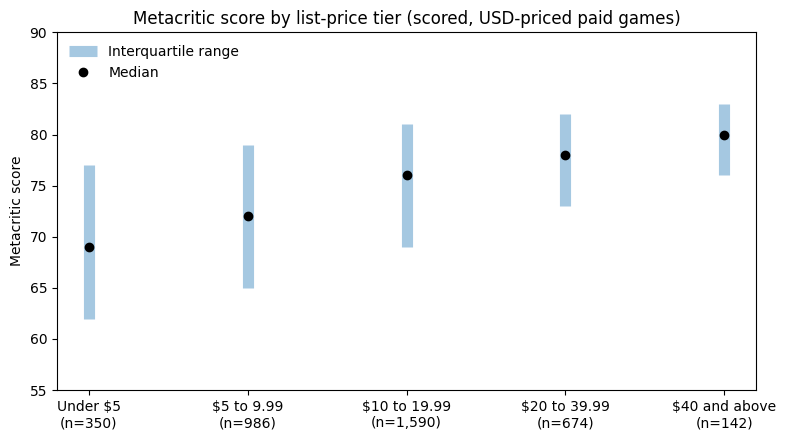

In [17]:
import matplotlib.pyplot as plt

plot_df = score_by_tier[score_by_tier["tier"] != "0 Free"].reset_index(drop=True)
labels = [f"{t[2:]}\n(n={n:,})".replace("$", r"\$")
          for t, n in zip(plot_df["tier"], plot_df["scored_games"])]
x = list(range(len(plot_df)))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.vlines(x, plot_df["p25"], plot_df["p75"], linewidth=8, alpha=0.4, label="Interquartile range")
ax.plot(x, plot_df["median_score"], "o", color="black", label="Median")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(55, 90)
ax.set_ylabel("Metacritic score")
ax.set_title("Metacritic score by list-price tier (scored, USD-priced paid games)")
ax.legend(loc="upper left", frameon=False)
fig.tight_layout()
fig.savefig("../docs/figures/q4_score_by_price_tier.png", dpi=150)  # same path pattern as the Q1/Q2 saves
plt.show()

**Conclusion: price tier versus Metacritic score.**
Among paid games with a Metacritic score and a USD list price (3,742), the median score rises with price: 69 (under USD 5), 72, 76, 78 and 80 (USD 40 and above). The interquartile range narrows from 15 points (under USD 5) to 7 points (USD 40 and above). Free games (114 scored out of 18,994, median 74.5) are reported but not placed on the price trend.
The scored subset is selected differently in each tier: the share of games with a score ranges from 0.6% (free) to 15.6% (USD 20 to 39.99), so the result describes scored games only.
A release-year control shows that part of the pooled gap is composition: 70% of scored Under USD 10 games are from 2015 or earlier, against 14% of scored USD 20+ games. Within cohorts, the Under USD 10 to USD 20+ median gap is 6.5 points (2011-2015) and 6.0 points (2016-2019), but only 1 point (2020-2025). The Up to 2010 gap (10 points) rests on 12 games in the top cell. The reason for the weaker recent gradient was not tested.
**Limits.** 310 scored games without a USD price are excluded. `price_usd` is the list price at the scrape date, not the price at release. The result is an association; it does not show that price affects reception.

## 6. Q5: Platform support over time

**Question.** How has the share of games supporting Windows, Mac and Linux changed by release year?

**Approach.** Platform support comes from the `game_platforms` link table. Shares are computed per release year against all games released that year. 2025 is a partial year (to 2025-09-29), and games with no release year are excluded from the trend.

In [18]:
platform_sql = """
SELECT
    g.release_year,
    COUNT(*)                                                         AS games,
    ROUND(100.0 * AVG(CASE WHEN w.appid IS NOT NULL THEN 1 ELSE 0 END), 1) AS pct_windows,
    ROUND(100.0 * AVG(CASE WHEN m.appid IS NOT NULL THEN 1 ELSE 0 END), 1) AS pct_mac,
    ROUND(100.0 * AVG(CASE WHEN l.appid IS NOT NULL THEN 1 ELSE 0 END), 1) AS pct_linux
FROM games g
LEFT JOIN game_platforms w ON w.appid = g.appid AND w.platform_id = 1
LEFT JOIN game_platforms m ON m.appid = g.appid AND m.platform_id = 2
LEFT JOIN game_platforms l ON l.appid = g.appid AND l.platform_id = 3
WHERE g.release_year IS NOT NULL
GROUP BY g.release_year
ORDER BY g.release_year
"""
platforms = q(platform_sql)
display(platforms)
print("Games:", platforms["games"].sum())

,release_year,games,pct_windows,pct_mac,pct_linux
0,1997,2,100.00,50.00,50.00
1,1998,1,100.00,100.00,100.00
2,1999,2,100.00,100.00,100.00
3,2000,2,100.00,100.00,100.00
4,2001,4,100.00,50.00,50.00
5,2002,1,100.00,0.00,0.00
6,2003,3,100.00,66.70,33.30
7,2004,5,100.00,40.00,100.00
8,2005,7,100.00,14.30,28.60
9,2006,63,100.00,22.20,15.90


Games: 114955


#### Figure for Q5

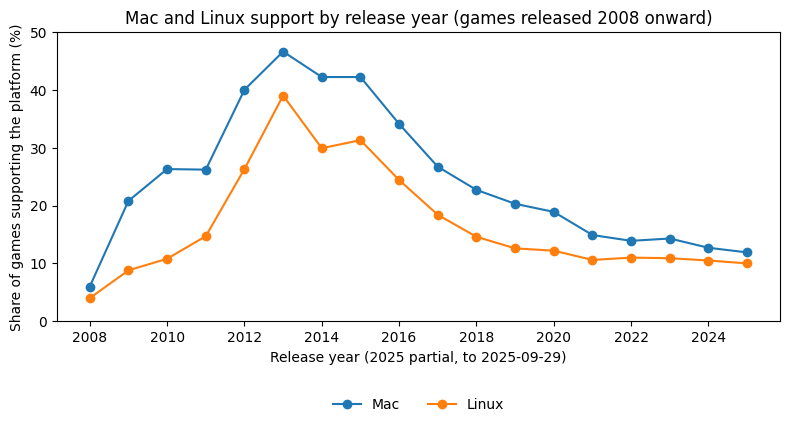

In [19]:
import matplotlib.pyplot as plt

plot_df = platforms[platforms["release_year"] >= 2008]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(plot_df["release_year"], plot_df["pct_mac"], marker="o", label="Mac")
ax.plot(plot_df["release_year"], plot_df["pct_linux"], marker="o", label="Linux")
ax.set_xticks(range(2008, 2026, 2))
ax.set_ylim(0, 50)
ax.set_xlabel("Release year (2025 partial, to 2025-09-29)")
ax.set_ylabel("Share of games supporting the platform (%)")
ax.set_title("Mac and Linux support by release year (games released 2008 onward)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=2, frameon=False)
fig.tight_layout()
fig.savefig("../docs/figures/q5_platform_share_by_year.png", dpi=150, bbox_inches="tight")
plt.show()

#### Counts versus shares (SQL check)

In [20]:
counts_sql = """
SELECT
    g.release_year,
    COUNT(*)                                        AS games,
    COUNT(m.appid)                                  AS mac_games,
    COUNT(l.appid)                                  AS linux_games
FROM games g
LEFT JOIN game_platforms m ON m.appid = g.appid AND m.platform_id = 2
LEFT JOIN game_platforms l ON l.appid = g.appid AND l.platform_id = 3
WHERE g.release_year IN (2013, 2015, 2018, 2021, 2024)
GROUP BY g.release_year
ORDER BY g.release_year
"""
display(q(counts_sql))

,release_year,games,mac_games,linux_games
0,2013,464,216,181
1,2015,2502,1056,783
2,2018,7438,1688,1086
3,2021,11066,1645,1173
4,2024,20203,2569,2128


**Conclusion: platform support over time.**
Windows support is effectively universal: 99.7 to 100% of games in every release year. The few exceptions (2012, 2017, 2019) amount to a handful of games.
Mac and Linux support rose to a peak with 2013 releases (46.6% Mac, 39.0% Linux), then fell steadily to 11.9% and 10.0% for 2025 releases. Linux has been nearly flat at 10 to 11% since 2021. The Mac-Linux gap narrowed from 7.6 points (2013) to 1.9 points (2025).
The decline is a falling share, not a falling count. Between 2013 and 2024, Mac-supporting games rose from 216 to 2,569 and Linux-supporting games from 181 to 2,128, while all games rose from 464 to 20,203. Between 2018 and 2021, Mac counts were roughly flat (1,688 to 1,645) while the total grew 49%. Only the five years in the table were checked exactly.
The cause of the 2013 peak and the later decline was not tested.
**Limits.** Support is the platform flag at scrape time, not at release, so ports added later count under the original release year. Years before 2008 have fewer than 151 games each and are not plotted. Games with no release year (23.5%) are excluded. 2025 is partial (to 2025-09-29).

## 7. Q6: Discounts at the scrape date

**Question.** What share of games were on sale on the scrape date, and does it differ by price tier?

**Approach.** `discount_percent` is a point-in-time snapshot (2025-09-29), so results describe that day only and say nothing about how often a game is discounted. Coverage is checked first, then the share on sale is computed per list-price tier against games that have a discount value.

In [21]:
discount_sql = """
SELECT
    CASE
        WHEN is_free = 1        THEN '0 Free'
        WHEN price_usd IS NULL  THEN '6 Paid, no USD price'
        WHEN price_usd < 5      THEN '1 Under $5'
        WHEN price_usd < 10     THEN '2 $5 to 9.99'
        WHEN price_usd < 20     THEN '3 $10 to 19.99'
        WHEN price_usd < 40     THEN '4 $20 to 39.99'
        ELSE                         '5 $40 and above'
    END AS tier,
    COUNT(*)                                                    AS games,
    COUNT(discount_percent)                                     AS with_value,
    SUM(CASE WHEN discount_percent > 0 THEN 1 ELSE 0 END)      AS on_sale,
    ROUND(100.0 * SUM(CASE WHEN discount_percent > 0 THEN 1 ELSE 0 END)
          / NULLIF(COUNT(discount_percent), 0), 1)              AS pct_on_sale,
    MAX(discount_percent)                                       AS max_discount
FROM games
GROUP BY 1
ORDER BY 1
"""
discounts = q(discount_sql)
display(discounts)
print("Total games:", discounts["games"].sum(), "| on sale:", discounts["on_sale"].sum())

,tier,games,with_value,on_sale,pct_on_sale,max_discount
0,0 Free,18994,0,0.00,NaN,<NA>
1,1 Under $5,43861,43861,"4,141.00",9.40,90
2,2 $5 to 9.99,23359,23359,"2,374.00",10.20,92
3,3 $10 to 19.99,16060,16060,"1,866.00",11.60,95
4,4 $20 to 39.99,4316,4316,674.00,15.60,95
5,5 $40 and above,1347,1347,212.00,15.70,95
6,"6 Paid, no USD price",42342,1368,190.00,13.90,95


Total games: 150279 | on sale: 9457.0


#### 7b Release-year control

In [22]:
discount_cohort_sql = """
SELECT
    CASE
        WHEN release_year IS NULL  THEN '5 Unknown year'
        WHEN release_year <= 2010  THEN '1 Up to 2010'
        WHEN release_year <= 2015  THEN '2 2011-2015'
        WHEN release_year <= 2019  THEN '3 2016-2019'
        ELSE                            '4 2020-2025'
    END AS cohort,
    CASE
        WHEN price_usd < 10  THEN '1 Under $10'
        WHEN price_usd < 20  THEN '2 $10 to 19.99'
        ELSE                      '3 $20 and above'
    END AS tier,
    COUNT(*)                                                    AS n,
    ROUND(100.0 * AVG(CASE WHEN discount_percent > 0 THEN 1 ELSE 0 END), 1) AS pct_on_sale
FROM games
WHERE is_free = 0
  AND price_usd IS NOT NULL
  AND discount_percent IS NOT NULL
GROUP BY 1, 2
ORDER BY 1, 2
"""
dc = q(discount_cohort_sql)
display(dc.pivot(index="cohort", columns="tier", values="n"))
display(dc.pivot(index="cohort", columns="tier", values="pct_on_sale"))
print("Games in control:", dc["n"].sum())

tier,1 Under $10,2 $10 to 19.99,3 $20 and above
cohort,,,
1 Up to 2010,635,142,15
2 2011-2015,3225,910,248
3 2016-2019,16108,3489,1070
4 2020-2025,47235,11515,4301
5 Unknown year,17,4,29


tier,1 Under $10,2 $10 to 19.99,3 $20 and above
cohort,,,
1 Up to 2010,7.70,12.70,33.30
2 2011-2015,12.70,12.20,14.50
3 2016-2019,9.00,9.40,13.60
4 2020-2025,9.70,12.20,16.20
5 Unknown year,11.80,0.00,10.30


Games in control: 88943


**Conclusion: discounts at the scrape date.**
On 2025-09-29, 9,457 of the 90,311 games with a price (10.5%) were on sale. Among the 88,943 USD-priced games, the share on sale rises with list price: 9.4% (under USD 5), 10.2%, 11.6%, 15.6% and 15.7% (USD 40 and above). The deepest discount seen is 95%.
A release-year control keeps the pattern in the two largest cohorts. The gap between Under USD 10 and USD 20 and above is 4.6 points for 2016-2019 and 6.5 points for 2020-2025, against about 6.0 pooled, and it is only 1.8 points for 2011-2015, where the order is not monotone. The Up to 2010 gap rests on 15 games and is not used. Cohort mix is similar across tiers (70% of Under USD 10 and 76% of USD 20+ games are from 2020-2025), so composition explains little. The reason higher tiers are more often on sale was not tested.
**Limits.** The result is a snapshot of one day and does not show how often games are discounted. Free games hold no discount value, so they cannot be assessed. The 1,368 games priced in other currencies (190 on sale) are not placed in a USD tier. The other 40,974 paid games have no price and no discount value, and they are concentrated in recent listings, so the result describes games with a price only.

## 8. Findings summary

The analysis covers 150,279 games from the cleaned database. Every result is an association in observational data, and each section's limits are stated in its conclusion cell.

| Question | Main finding | Main limit |
|---|---|---|
| Q1: Free share by release year | Free games rise from about 2-3% of releases (2006-2010) to 14.0-15.6% for each year 2019-2024 (12.2% in partial 2025). The `is_free` flag is used as the definition. | 30.0% of free games lack the Free to Play tag. The 2024-25 convergence of tag and flag shares comes only from free games, and its cause was not tested. |
| Q2: Genre mix by year | Indie ranks first every year 2015-2024 (67.7-77.3%). Casual overtakes Action in 2018 and stays in a 42.4-46.2% band. Action falls from 44.3% (2017) to 38.9% (2024). | A game counts once per genre, so shares exceed 100%. The size of Casual's gain depends on the comparison window. |
| Q3: Publisher size vs reception | The share of a publisher's games with recommendations reported rises from 5.7% (1 game) to 32.8% (21+ games), and holds in every release-year cohort. The median recommendation count among reporting games is flat (322-353). | Recommendations measure reach, not quality. Part of the pooled gap is composition. The Metacritic comparison uses small, selected samples. |
| Q4: Price tier vs Metacritic | Among 3,742 scored paid games, the median score rises with price: 69, 72, 76, 78, 80.The gap between Under USD 10 and USD 20+ is about 6 points in 2011-2015 and 2016-2019, and 1 point in 2020-2025. | Only 2.8% of games have a score, and the scored share varies from 0.6% to 15.6% by tier. Price is the scrape-date list price. |
| Q5: Platform support | Windows is at 99.7-100% in every year. Mac and Linux peak for 2013 releases (46.6% and 39.0%) and fall to 11.9% and 10.0% for 2025. The fall is a growing denominator, not fewer games (Mac 216 to 2,569 from 2013 to 2024). | Support is the flag at scrape time, not at release. The cause of the peak and decline was not tested. |
| Q6: Discounts at scrape date | On 2025-09-29, 10.5% of games with a price were on sale. The share rises with list price, from 9.4% to 15.7%, and the pattern holds in the two largest release-year cohorts. | One-day snapshot. Free games and 40,974 paid games have no discount value. |

**Cross-cutting limits.**
- Missing data is not random. Prices are missing more often for recent listings, Metacritic scores cover 2.8% of games, and recommendations cover 13.2%.
- Where a pooled gap was checked inside release-year cohorts, it sometimes shrank (Q3, Q4) and sometimes held (Q6). Composition effects were therefore tested rather than assumed.
- No causal claim is made anywhere. Explanations that were not tested are labelled as hypotheses in the sections.